In [1]:
import scion
import ENDFtk

In [ ]:
# ENDF/B-VI.8 data for Cm244
cm244_endf68 = ENDFtk.tree.Tape.from_file( '/Users/wim/Projects/libraries/endf/endf68/neutrons/n-96244.endf' )

data_endf68 = scion.from_endf( cm244_endf68.materials.front().file(1).section(452).parse() )

# the nubar data is given as a polynomial series
print( data_endf68 )
print( data_endf68.coefficients )

# linearise the data
data_endf68 = data_endf68.linearise()

# the nubar data is now a lin-lin table
print( data_endf68 )
print( data_endf68.x )
print( data_endf68.y )

In [ ]:
# ENDF/B-VIII.0 data for Cm244
cm244_endf80 = ENDFtk.tree.Tape.from_file( '/Users/wim/Projects/libraries/endf/endf80/neutrons/n-096_Cm_244.endf' )

data_endf80 = scion.from_endf( cm244_endf80.materials.front().file(1).section(452).parse() )

# the nubar data is a lin-lin table
print( data_endf80 )
print( data_endf80.x )
print( data_endf80.y )

In [ ]:
import matplotlib.pyplot as plot

# plot the data
plot.figure()
plot.plot( data_endf68.x, data_endf68.y, label = '${}^{244}$Cm nubar ENDF/B-VI.8', color = 'red', linewidth = 1.0 )
plot.plot( data_endf80.x, data_endf80.y, label = '${}^{244}$Cm nubar ENDF/B-VIII.0', color = 'blue', linewidth = 1.0 )
plot.xlabel( 'Energy (eV)' )
plot.ylabel( 'Neutrons per fission' )
plot.title( 'ENDF/B-VI.8 versus ENDF/B-VIII.0' )
plot.xlim( 1e-5, 10e+6 )
plot.xscale( 'log' )
plot.yscale( 'linear' )
plot.legend()
plot.show()

In [15]:
import scion
import ENDFtk

# convert to the proper Legendre coefficients
def convert( data, index ) :
    
    coefficients = data.angular_distributions[index].coefficients
    converted = [ 0.5 ]
    for i in range( 1, len( coefficients ) + 1 ) :
        
        converted.append( ( 2 * i + 1 ) / 2 * coefficients[i - 1] )
    
    return converted

# open the U235 data and extract the elastic angular distribution data for neutrons
u235 = ENDFtk.tree.Tape.from_file( 'h1.endf' )
elastic = u235.materials.front().file( 4 ).section( 2 ).parse()

# retrieve the angular distributions at different energies
distribution1 = scion.math.LegendreSeries( convert( elastic, 0 ) )
distribution2 = scion.math.LegendreSeries( convert( elastic, -11 ) )
distribution3 = scion.math.LegendreSeries( convert( elastic, -1 ) )


<IPython.core.display.Javascript object>


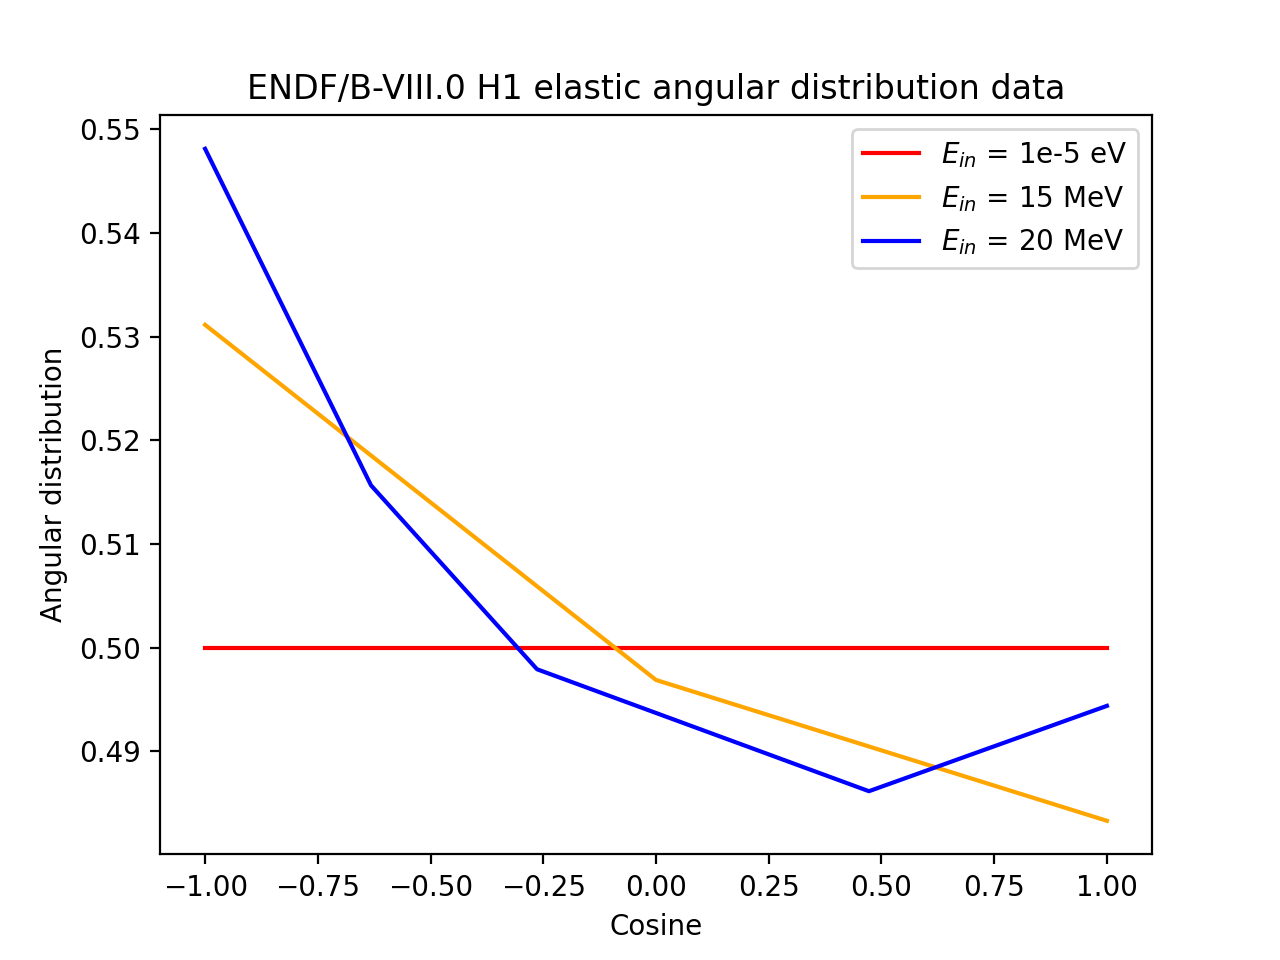

In [29]:
import matplotlib.pyplot as plot
%matplotlib notebook

tolerance = scion.linearisation.ToleranceConvergence( .01 )
plot1 = distribution1.linearise(tolerance)
plot2 = distribution2.linearise(tolerance)
plot3 = distribution3.linearise(tolerance)

# plot the data
plot.figure()
plot.plot( plot1.x, plot1.y, label = '$E_{in}$ = 1e-5 eV', color = 'red', linewidth = 1.5 )
plot.plot( plot2.x, plot2.y, label = '$E_{in}$ = 15 MeV', color = 'orange', linewidth = 1.5 )
plot.plot( plot3.x, plot3.y, label = '$E_{in}$ = 20 MeV', color = 'blue', linewidth = 1.5 )
plot.xlabel( 'Cosine' )
plot.ylabel( 'Angular distribution' )
plot.title( 'ENDF/B-VIII.0 H1 elastic angular distribution data' )
plot.legend()
plot.show()

In [5]:
len(plot3.x)

466

In [ ]:
distribution3.derivative().roots()

In [ ]:
distribution3.order

<IPython.core.display.Javascript object>


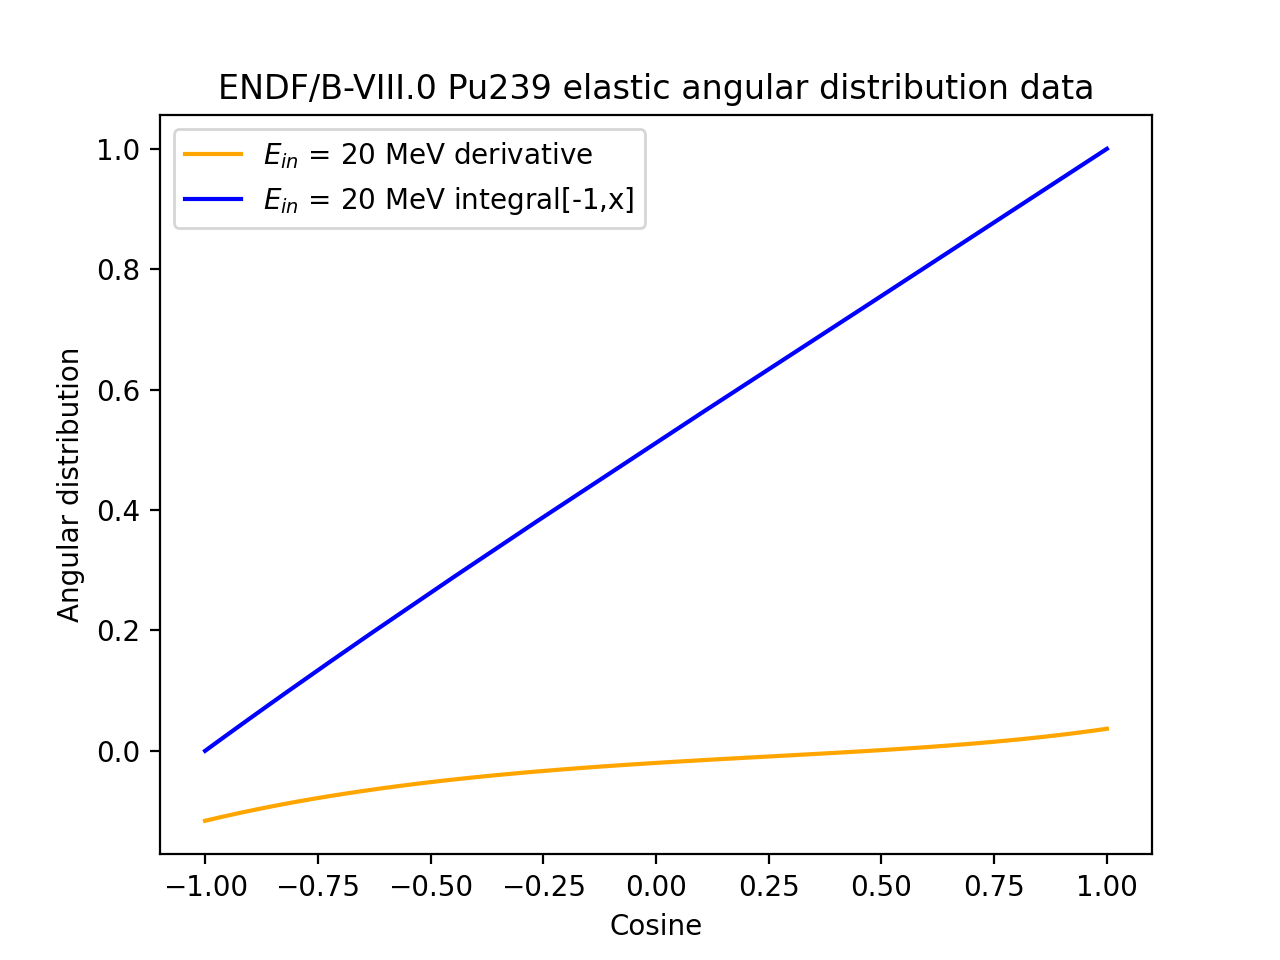

In [19]:
import matplotlib.pyplot as plot

tolerance = scion.linearisation.ToleranceConvergence( .001 )
plot1 = distribution3.linearise(tolerance)
plot2 = distribution3.derivative().linearise(tolerance)
plot3 = distribution3.primitive( -1 ).linearise(tolerance)

# plot the data
plot.figure()
#plot.plot( plot1.x, plot1.y, label = '$E_{in}$ = 20 eV', color = 'red', linewidth = 1.5 )
plot.plot( plot2.x, plot2.y, label = '$E_{in}$ = 20 MeV derivative', color = 'orange', linewidth = 1.5 )
plot.plot( plot3.x, plot3.y, label = '$E_{in}$ = 20 MeV integral[-1,x]', color = 'blue', linewidth = 1.5 )
plot.xlabel( 'Cosine' )
plot.ylabel( 'Angular distribution' )
plot.title( 'ENDF/B-VIII.0 Pu239 elastic angular distribution data' )
plot.legend()
plot.show()

In [20]:
distribution3(-1)

0.5481180770095

In [21]:
plot3(-.812)

0.10116517107943511

In [30]:
pdf = scion.math.LinearLinearTable( [ -1.00000000000E+00,  -8.12000000000E-01,  -5.62000000000E-01,
                                      -2.50000000000E-01,   1.25000000000E-01,   5.00000000000E-01,   
                                       8.13000000000E-01,   1.00000000000E+00 ],
                                    [  5.47551700000E-01,   5.28641500000E-01,   5.10853500000E-01,
                                       4.96942600000E-01,   4.88205900000E-01,   4.85679900000E-01,   
                                       4.88715100000E-01,   4.93884300000E-01 ])

cdf = scion.math.LinearLinearTable( [ -1.00000000000E+00,  -8.12000000000E-01,  -5.62000000000E-01,
                                      -2.50000000000E-01,   1.25000000000E-01,   5.00000000000E-01,   
                                       8.13000000000E-01,   1.00000000000E+00 ],
                                    [  0.00000000000E+00,   1.01162200000E-01,   2.31099100000E-01,
                                       3.88315300000E-01,   5.73030600000E-01,   7.55634200000E-01,
                                       9.08127000000E-01,  1.00000000000E+00 ])

<IPython.core.display.Javascript object>


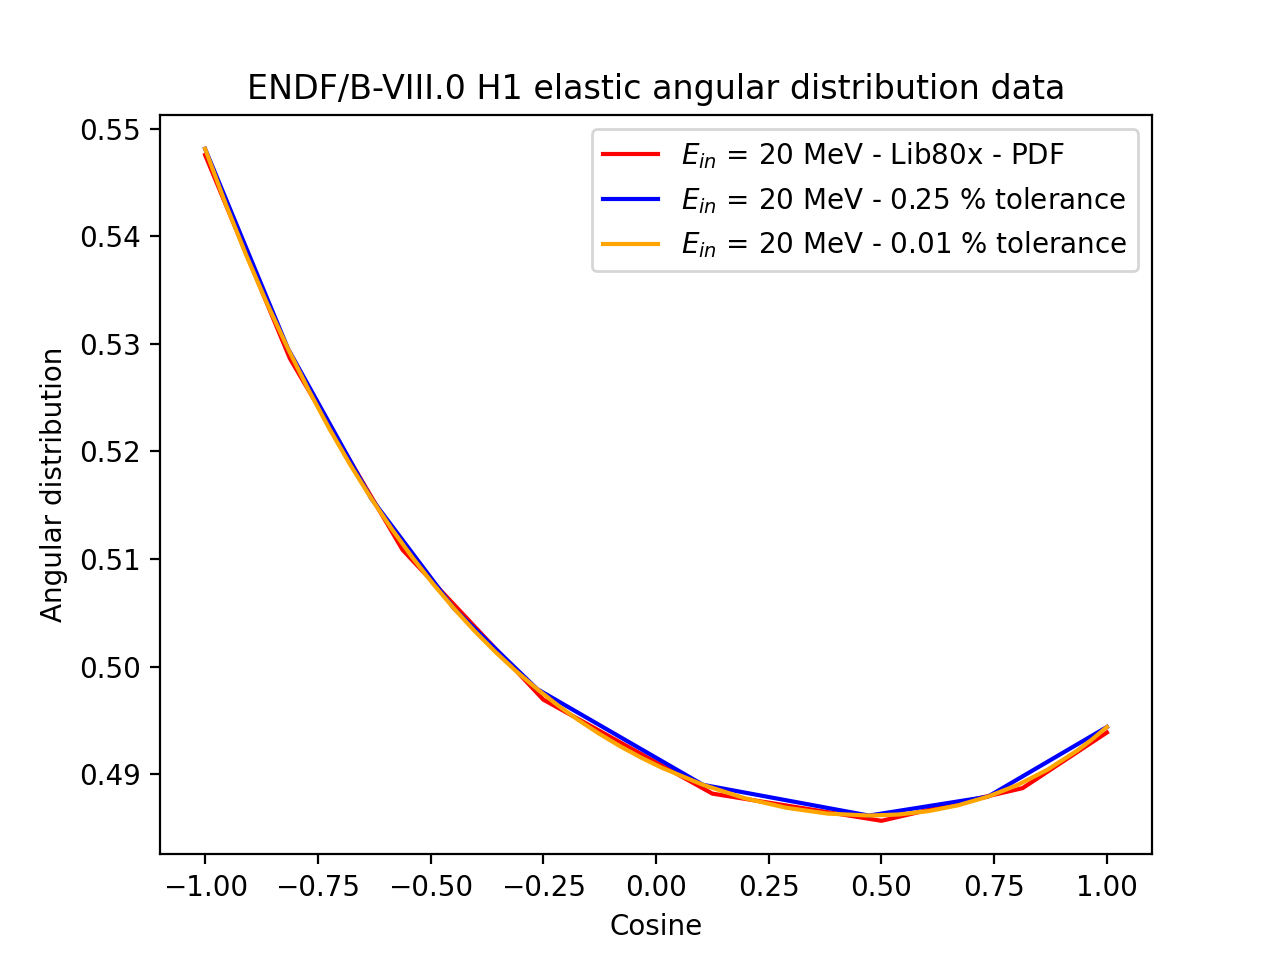

In [48]:
import matplotlib.pyplot as plot

plot1 = distribution3.linearise( scion.linearisation.ToleranceConvergence( .0025 ) )
plot2 = distribution3.linearise( scion.linearisation.ToleranceConvergence( .0001 ) )

# plot the data
plot.figure()
plot.plot( pdf.x, pdf.y, label = '$E_{in}$ = 20 MeV - Lib80x - PDF', color = 'red', linewidth = 1.5 )
plot.plot( plot1.x, plot1.y, label = '$E_{in}$ = 20 MeV - 0.25 % tolerance', color = 'blue', linewidth = 1.5 )
plot.plot( plot2.x, plot2.y, label = '$E_{in}$ = 20 MeV - 0.01 % tolerance', color = 'orange', linewidth = 1.5 )
plot.xlabel( 'Cosine' )
plot.ylabel( 'Angular distribution' )
plot.title( 'ENDF/B-VIII.0 H1 elastic angular distribution data' )
plot.legend()
plot.show()

In [44]:
print(len(plot1.x))
print(len(plot2.x))


9
37


<IPython.core.display.Javascript object>


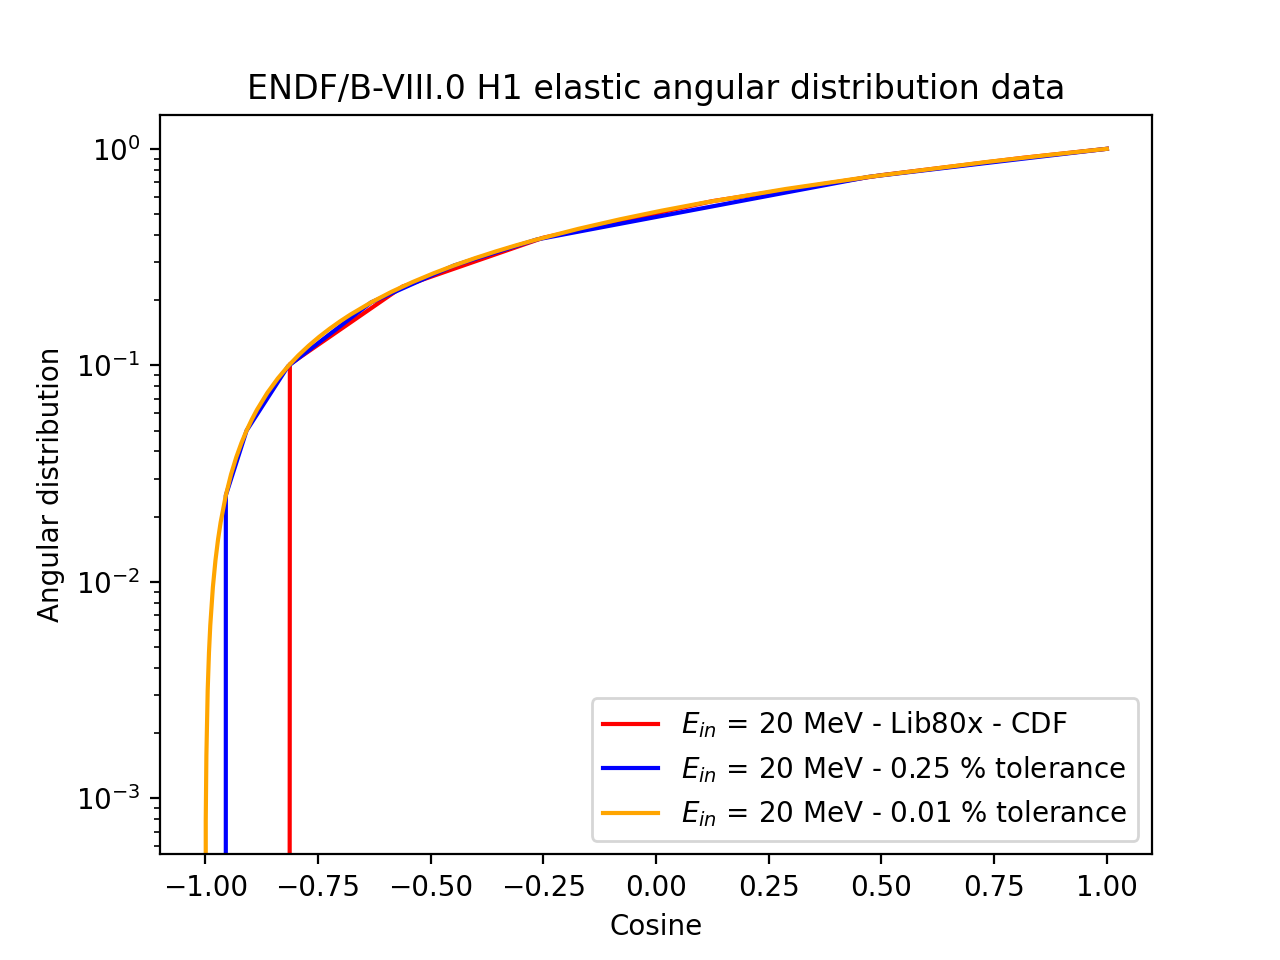

In [47]:
import matplotlib.pyplot as plot

plot1 = distribution3.primitive(-1).linearise( scion.linearisation.ToleranceConvergence( .0025 ) )
plot2 = distribution3.primitive(-1).linearise( scion.linearisation.ToleranceConvergence( .0001 ) )

# plot the data
plot.figure()
plot.plot( cdf.x, cdf.y, label = '$E_{in}$ = 20 MeV - Lib80x - CDF', color = 'red', linewidth = 1.5 )
plot.plot( plot1.x, plot1.y, label = '$E_{in}$ = 20 MeV - 0.25 % tolerance', color = 'blue', linewidth = 1.5 )
plot.plot( plot2.x, plot2.y, label = '$E_{in}$ = 20 MeV - 0.01 % tolerance', color = 'orange', linewidth = 1.5 )
plot.xlabel( 'Cosine' )
plot.ylabel( 'Angular distribution' )
plot.title( 'ENDF/B-VIII.0 H1 elastic angular distribution data' )
plot.yscale( 'log' )
plot.legend()
plot.show()